In [2]:
# Extend the analysis of Zhang & Callies to 2D spectra
# see : https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2025JC022879
# first tests use the track most used in their paper: 

import netCDF4 as nc
import glob
import xarray as xr
import xrft
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
from scipy.special import gamma, kv
from numpy.linalg import inv
import mpmath as mp
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import math
from math import sin, cos, sqrt, atan2, radians
import datetime
from matplotlib import pyplot as plt, animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
#import swot_analysis as swot
import scipy.signal as signal
import numpy as np
from scipy.ndimage import gaussian_filter
import scipy.io as sio
from scipy.stats import chi2
import scipy.stats as stats
#import h5py


In [3]:
pass_number = 28
dirroot='/media/ardhuin/FabLinux/'
path1=dirroot+'SWOT2/Basic_D/*/'
path2=dirroot+'SWOT2/WindWave/'
min_cycle = 474
max_cycle = 578
lat_min = -56.5
lat_max = -53.5
num_cycles = max_cycle - min_cycle + 1

print('TEST:',path1+'SWOT_L2_LR_SSH_Basic_'+str(max_cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')

TEST: /media/ardhuin/FabLinux/SWOT2/Basic_D/*/SWOT_L2_LR_SSH_Basic_578_028_*.nc


In [4]:
# find the first cycle which contains the selected path
found_nothing = True
cycle = min_cycle - 1

while (found_nothing == True):
    cycle +=1
    path = glob.glob(path1+'SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    print('cycle:',cycle,path)
    # path = glob.glob('../SWOT_L2_LR_SSH_1.1/SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    if path == []:
        continue
    else:
        found_nothing = False

if (found_nothing == False):
    print(path)

cycle: 474 ['/media/ardhuin/FabLinux/SWOT2/Basic_D/cycle_474/SWOT_L2_LR_SSH_Basic_474_028_20230329T210138_20230329T215244_PGD0_01.nc']
['/media/ardhuin/FabLinux/SWOT2/Basic_D/cycle_474/SWOT_L2_LR_SSH_Basic_474_028_20230329T210138_20230329T215244_PGD0_01.nc']


In [5]:
first_pass_data = nc.Dataset(path[0], 'r')
fp_latitude = first_pass_data['latitude']
fp_shape = np.shape(fp_latitude)
# left_edge = fp_shape[1] - 6
#we are ignoring the five outer grid points, but subtract 6 because of Python's zero indexing
lat_edge = fp_latitude[:,35]

#find min and max line indices
indx = np.nonzero((lat_edge >= lat_min) & (lat_edge <= lat_max))[0]
track_length = np.shape(indx)[0]
print(track_length)

177


In [6]:
#find cycles with given pass
cycle_list = np.empty(0)
num_useful_cycles = 0
for cycle in range(min_cycle,max_cycle+1):
    # path = glob.glob('../SWOT_L2_LR_SSH_1.1/SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    path = glob.glob(path1+'SWOT_L2_LR_SSH_Basic_'+str(cycle).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    if path == []:
        continue
    else:
        cycle_list = np.append(cycle_list,cycle)
        num_useful_cycles += 1

print(num_useful_cycles)

100


In [7]:
lat_array = np.empty((num_useful_cycles,2,track_length,25))
lat_array[:] = np.nan
lon_array = np.empty((num_useful_cycles,2,track_length,25))
lon_array[:] = np.nan
ssha_array = np.empty((num_useful_cycles,2,track_length,25))
ssha_array[:] = np.nan
tides = np.empty((num_useful_cycles,2,track_length,25))
tides[:] = np.nan
time_array = np.empty((num_useful_cycles,2,track_length))
time_array[:] = np.nan
num_useful_strips = 0
num_bad_strips = 0
good_strips_list = np.array([[0,0]])
for n,cycle in enumerate(cycle_list):
    path = glob.glob(path1+'SWOT_L2_LR_SSH_Basic_'+str(int(cycle)).zfill(3)+'_'+str(pass_number).zfill(3)+'_*.nc')
    if path == []:
        continue
    data = nc.Dataset(path[0],'r')
    ssha_strip = data['ssha_karin_2'][indx,:]
    # ssha_strip = data['ssha_karin'][indx,:]
    ssha_qual = data['ssha_karin_2_qual'][indx,:]
    xover_cor = data['height_cor_xover'][indx,:]# Additional correction provided by SWOT
    xover_cor_qual = data['height_cor_xover_qual'][indx,:]# Additional quality flag
    internal_tide_hret = data['internal_tide_hret'][indx,:] #internal tide correction I will add back  
    lat_strip = data['latitude'][indx,:]
    lon_strip = data['longitude'][indx,:]
    time_strip = data['time'][indx]
    for side in range(2):
        start_index = 5 + 34*side
        if np.ma.is_masked(ssha_strip[:,start_index:(start_index + 25)]) == True:
            num_bad_strips +=1
            continue
        if np.ma.is_masked(xover_cor[:,start_index:(start_index + 25)]) == True:
            num_bad_strips +=1
            continue
        if np.any(ssha_qual[:,start_index:(start_index + 25)]) == True: 
            num_bad_strips +=1
            continue
        num_useful_strips +=1
        lat_array[n,side,:,:] = lat_strip[:,start_index:(start_index + 25)]
        lon_array[n,side,:,:] = lon_strip[:,start_index:(start_index + 25)]
        ssha_array[n,side,:,:] = ssha_strip[:,start_index:(start_index + 25)] + xover_cor[:,start_index:(start_index + 25)] - internal_tide_hret[:,start_index:(start_index + 25)]
        tides[n,side,:,:] = internal_tide_hret[:,start_index:(start_index + 25)]
        time_array[n,side,:] = time_strip
        good_strips_list = np.concatenate((good_strips_list,[[n,side]]))
    data.close()
good_strips_list = np.delete(good_strips_list,0,0)

In [8]:
print(num_useful_strips)

116


In [9]:
# # time-mean and filtered time-mean of SSH (for each of the swath)
print('shape of ssha_array:',np.shape(ssha_array))
ssha_mean = np.nanmean(ssha_array,axis=0)
ssha_med = np.nanmedian(ssha_array,axis=0)

shape of ssha_array: (100, 2, 177, 25)


In [10]:
# 2D Gaussian filter
cutoff_m = 100e3  
delta = 2e3
# Convert cutoff to sigma in pixels (Gaussian sigma ~ cutoff / (2 * sqrt(2 * ln(2)))
sigma_m = cutoff_m / (2 * np.sqrt(2 * np.log(2)))  # FWHM to sigma
sigma_pixels = sigma_m / delta

# Apply low-pass Gaussian filter
lowpass = gaussian_filter(ssha_mean, sigma=(0, sigma_pixels, sigma_pixels))  # no smoothing in time axis
lowpassm = gaussian_filter(ssha_med, sigma=(0, sigma_pixels, sigma_pixels))  # no smoothing in time axis

# High-pass filter: original - low-pass
ssha_mean_gaussian = ssha_mean - lowpass
ssha_med_gaussian = ssha_med - lowpass

In [11]:
x0 = 2*np.arange(track_length)
y0 = -2*np.arange(25)
x1,y1=np.meshgrid(x0,y0)

Text(0.5, 1.0, '2D Gaussian filter')

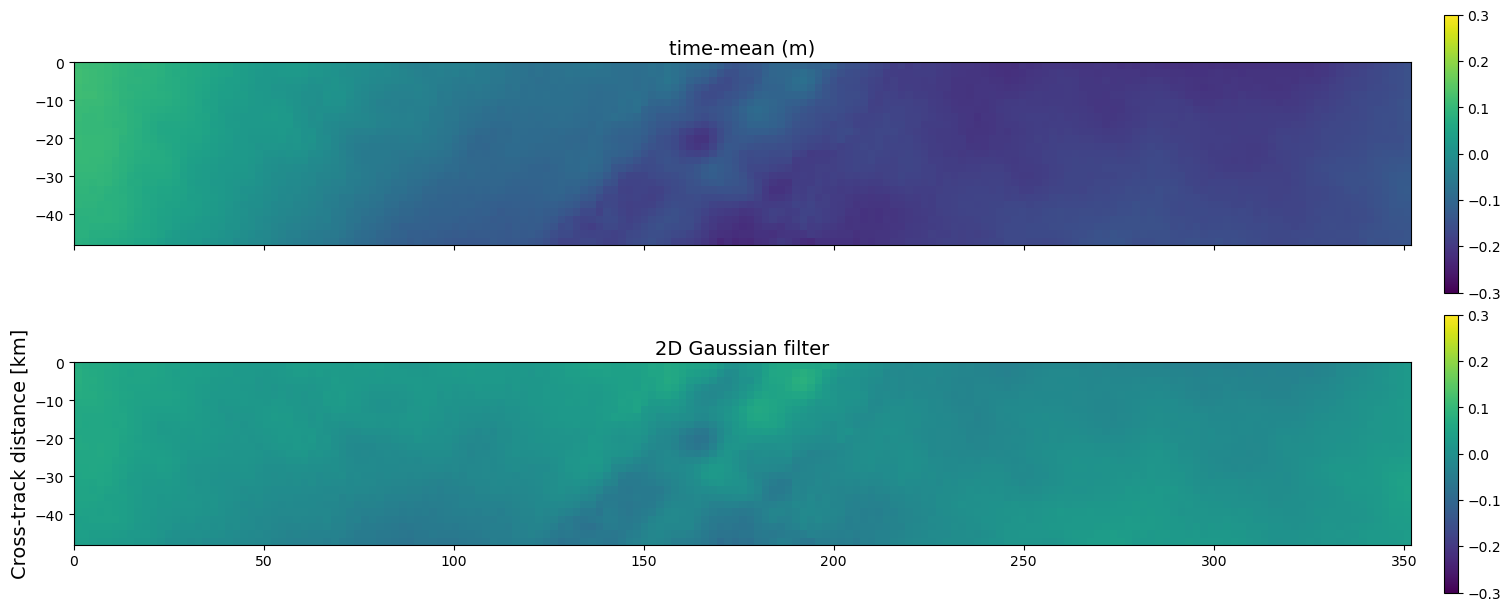

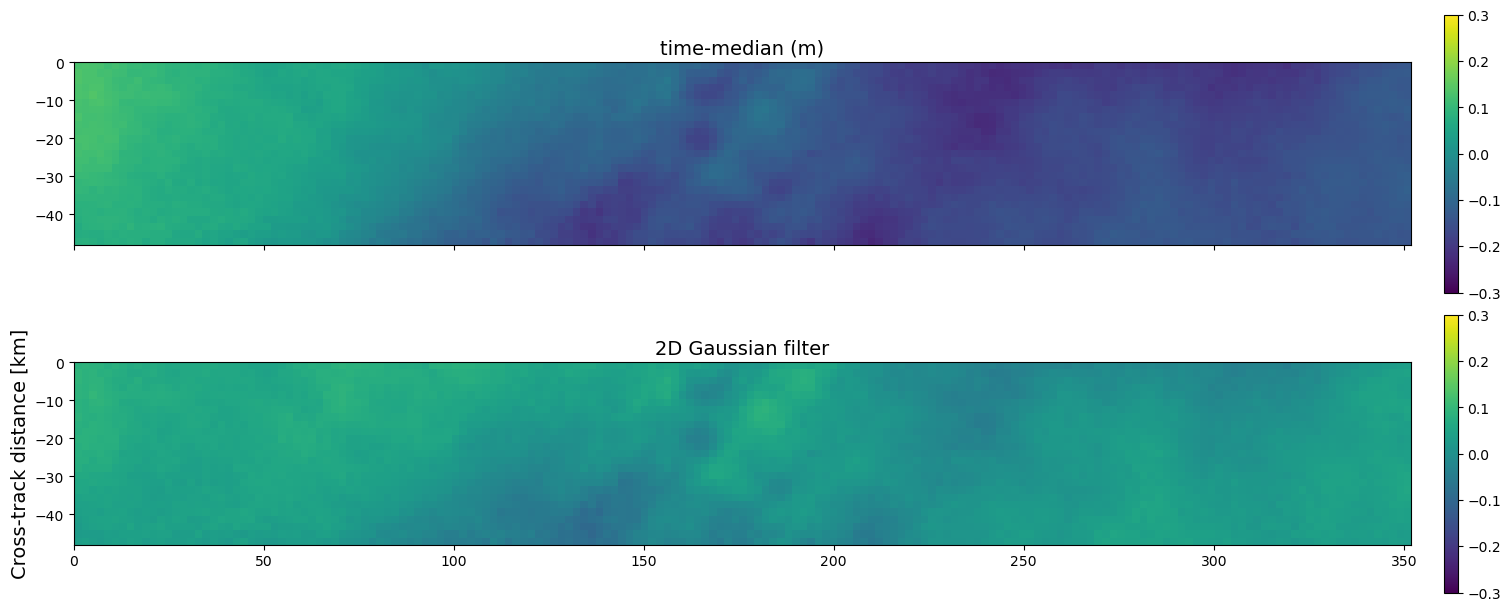

In [12]:
side = 0
fig,ax = plt.subplots(2,1,figsize=(15,6), sharex=True,constrained_layout=True)

cl = ax[0].imshow(ssha_mean[side,:,:].T,cmap = 'viridis',vmin=-0.3,vmax=0.3,\
                  extent=[np.min(x1), np.max(x1), np.min(y1), np.max(y1)], aspect = 'equal')#aspect='auto')
plt.colorbar(cl,pad = 0.02)
ax[0].set_title('time-mean (m)',loc = 'center', fontsize=14)

cl3 = ax[1].imshow(ssha_mean_gaussian[side,:,:].T, cmap='viridis', vmin=-0.3, vmax=0.3, 
                    extent=[np.min(x1), np.max(x1), np.min(y1), np.max(y1)], aspect = 'equal')#aspect='auto')
plt.colorbar(cl3,pad=0.02)
ax[1].set_ylabel('Cross-track distance [km]',fontsize = 14)
ax[1].set_title('2D Gaussian filter',loc = 'center',fontsize=14)

fig,ax = plt.subplots(2,1,figsize=(15,6), sharex=True,constrained_layout=True)

cl = ax[0].imshow(ssha_med[side,:,:].T,cmap = 'viridis',vmin=-0.3,vmax=0.3,\
                  extent=[np.min(x1), np.max(x1), np.min(y1), np.max(y1)], aspect = 'equal')#aspect='auto')
plt.colorbar(cl,pad = 0.02)
ax[0].set_title('time-median (m)',loc = 'center', fontsize=14)

cl3 = ax[1].imshow(ssha_med_gaussian[side,:,:].T, cmap='viridis', vmin=-0.3, vmax=0.3, 
                    extent=[np.min(x1), np.max(x1), np.min(y1), np.max(y1)], aspect = 'equal')#aspect='auto')
plt.colorbar(cl3,pad=0.02)
ax[1].set_ylabel('Cross-track distance [km]',fontsize = 14)
ax[1].set_title('2D Gaussian filter',loc = 'center',fontsize=14)

In [13]:
# Gaussian filter 
ssha_arrayanomly_gs = ssha_array - ssha_mean_gaussian[None,:,:,:] # anomalies from high-pass time-mean
sshaspmean_gs = np.nanmean(ssha_arrayanomly_gs,axis=tuple((2,3))) # spatial mean of ssha anomalies (at each time) from high pass time-mean
ssha_arrayanomlysp_gs = ssha_arrayanomly_gs - sshaspmean_gs[:,:,None,None]

/tmp/ipykernel_6141/2609242630.py:3: RuntimeWarning: Mean of empty slice
  sshaspmean_gs = np.nanmean(ssha_arrayanomly_gs,axis=tuple((2,3))) # spatial mean of ssha anomalies (at each time) from high pass time-mean


In [14]:
time_sp_mean  = np.nanmean(ssha_mean,axis = tuple((1,2)))
ssha_mean_sp = ssha_mean - time_sp_mean[:,None,None]# subtract spatial mean of time-mean from time-mean

time_sp_mean_filtered  = np.nanmean(ssha_mean_gaussian,axis = tuple((1,2)))
ssha_mean_filtered_sp = ssha_mean_gaussian - time_sp_mean_filtered[:,None,None]# subtract spatial mean of time-mean from time-mean

time_sp_med  = np.nanmedian(ssha_med,axis = tuple((1,2)))
ssha_med_sp = ssha_mean - time_sp_med[:,None,None]# subtract spatial mean of time-mean from time-mean
time_sp_med_filtered  = np.nanmedian(ssha_med_gaussian,axis = tuple((1,2)))
ssha_med_filtered_sp = ssha_med_gaussian - time_sp_med_filtered[:,None,None]# subtract spatial mean of time-mean from time-mean


In [15]:
lon_new = (lon_strip + 180) % 360 -180
ssha2swath = np.empty(lon_strip.shape)
ssha2swath[:] = np.nan

ssha2swath[:,5:5+25] = ssha_mean_filtered_sp[0,:,:] # time-mean (spatial mean removed)
ssha2swath[:,39:39+25] = ssha_mean_filtered_sp[1,:,:]

In [16]:
ncyc = 24 # cycle 510
ssha2swath_anomsnp = np.empty(lon_strip.shape)
ssha2swath_anomsnp[:] = np.nan
ssha2swath_anomsnp[:,5:5+25] = ssha_arrayanomlysp_gs[ncyc,0,:,:]
ssha2swath_anomsnp[:,39:39+25] = ssha_arrayanomlysp_gs[ncyc,1,:,:]

In [17]:
# select useful stripe only for each of the array
ssha_array_spmean = np.nanmean(ssha_array,axis = tuple((2,3)))
ssha_array_full = ssha_array - ssha_array_spmean[:,:,None,None] # subtract spatial mean to get full signals 

data_array = np.zeros((num_useful_strips, track_length, 25)) # full signal
data_array_gs = np.zeros((num_useful_strips, track_length, 25)) # anomalies from high pass Gaussian time-mean and spatial mean
for strip in range(num_useful_strips):
    cycle_index = good_strips_list[strip,0]
    side_index = good_strips_list[strip,1]
    data_array[strip,:,:] = ssha_array_full[cycle_index, side_index,:,:] # full signal
    data_array_gs[strip,:,:] = ssha_arrayanomlysp_gs[cycle_index, side_index,:,:]

/tmp/ipykernel_6141/258158673.py:2: RuntimeWarning: Mean of empty slice
  ssha_array_spmean = np.nanmean(ssha_array,axis = tuple((2,3)))


In [18]:
def spectrum_compute(data,num_useful_strips,track_length):
    samples = np.arange(num_useful_strips)
    y = 2e3*np.arange(track_length) #distance along track in km (because the resolution is 2kmX2km grid)
    x = 2e3*np.arange(25) #distance across track in km
    data_x = xr.DataArray(data, coords = [samples, y, x], dims = ['sample', 'line', 'pixel'])# convert to dataArray and cm
    window_x = xr.DataArray(np.sqrt(8./3.)*np.sin(np.pi*np.arange(track_length)/track_length)**2, dims = ['line'])
    windowed_per_pixel = data_x*window_x
    pspec_alongtrack = xrft.power_spectrum(windowed_per_pixel, dim = 'line')
    spec = pspec_alongtrack.mean(dim = ['sample','pixel'])
    return spec,pspec_alongtrack
    
def spectrum_compute_1sided(data,num_useful_strips,track_length,ncross=25):
    dx = 2e3
    window = np.sqrt(8./3.)*np.sin(np.pi*np.arange(track_length)/track_length)**2
    window_3d = np.broadcast_to(window.reshape(1, track_length, 1), (num_useful_strips, track_length, ncross))
    windowed = data * window_3d
    amp = np.fft.rfft(windowed,axis=1)# rfft applied to windowed ssh [sample,y/2,x]
    ampsq = dx*(np.abs(amp))**2/track_length
    ampsq_1side = np.empty(ampsq.shape)
    ampsq_1side[:]=np.nan
    ampsq_1side[:,1:,:]=2*ampsq[:,1:,:]
    ampsq_1side[:,0,:] = ampsq[:,0,:]
    spec_1side_ts = np.nanmean(ampsq_1side,axis = 2 )
    spec_1side = np.nanmean(ampsq_1side,axis=tuple([0,2]))
    return spec_1side,spec_1side_ts

In [19]:
# rfft for windowed ssha
dx = 2e3
k = np.fft.rfftfreq(track_length, dx)# rfft wave number cpm
print('shape of ssha ...:',np.shape(data_array_gs),'##',track_length)

shape of ssha ...: (116, 177, 25) ## 177


In [20]:
spec_1side_mean_gs, _ = spectrum_compute_1sided(ssha_mean_filtered_sp,2,track_length)
spec_1side_mean,_ = spectrum_compute_1sided(ssha_mean_sp,2,track_length,ncross=25)

spec_1side_med_gs, _ = spectrum_compute_1sided(ssha_med_filtered_sp,2,track_length)
spec_1side_med,_ = spectrum_compute_1sided(ssha_med_sp,2,track_length,ncross=25)

### Single Sided PSD

In [21]:
specfull1s,_ = spectrum_compute_1sided(data_array,num_useful_strips,track_length)
specanom_gs1s,specanom_gs1s_ts = spectrum_compute_1sided(data_array_gs,num_useful_strips,track_length)
specanom_gs1s_nar,specanom_gs1s_ts_nar = spectrum_compute_1sided(data_array_gs[:,:,3:23],num_useful_strips,track_length,ncross=20)
specanom_gs1s_mid,specanom_gs1s_ts_mid = spectrum_compute_1sided(data_array_gs[:,:,6:18],num_useful_strips,track_length,ncross=12)
data_smooth=0.25*data_array_gs[:,:,5:17]+0.5*data_array_gs[:,:,6:18]+0.25*data_array_gs[:,:,7:19]
data_smooth=0.15*data_array_gs[:,:,4:16]+0.35*data_array_gs[:,:,5:17]+0.35*data_array_gs[:,:,6:18]+0.15*data_array_gs[:,:,7:19]
specanom_gs1s_mis,specanom_gs1s_ts_mis = spectrum_compute_1sided(data_smooth,num_useful_strips,track_length,ncross=12)
print('shape of ssha ...:',num_useful_strips,np.shape(data_array_gs), np.shape(specanom_gs1s),np.shape(specanom_gs1s_ts))

shape of ssha ...: 116 (116, 177, 25) (89,) (116, 89)


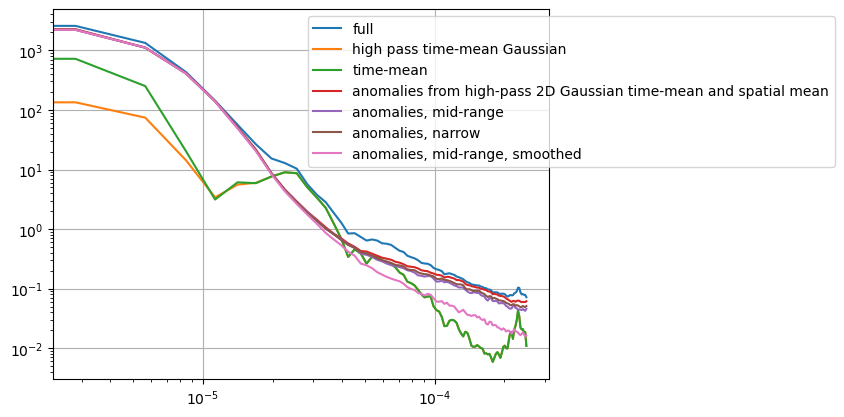

In [22]:
plt.loglog(k,specfull1s,label ='full')
plt.loglog(k,spec_1side_mean_gs, label = 'high pass time-mean Gaussian')
plt.loglog(k,spec_1side_mean, label = 'time-mean')
#plt.loglog(k,spec_1side_med_gs, label = 'high pass time-median Gaussian')
#plt.loglog(k,spec_1side_med, label = 'time-median')
plt.loglog(k,specanom_gs1s,label = 'anomalies from high-pass 2D Gaussian time-mean and spatial mean')
plt.loglog(k,specanom_gs1s_mid,label = 'anomalies, mid-range')
plt.loglog(k,specanom_gs1s_nar,label = 'anomalies, narrow')
plt.loglog(k,specanom_gs1s_mis,label = 'anomalies, mid-range, smoothed')
plt.legend(bbox_to_anchor = (0.5,1))
plt.grid(True)

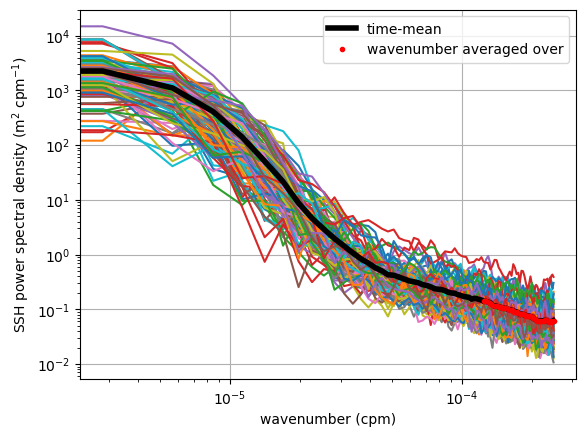

In [23]:
for n in range(specanom_gs1s_ts.shape[0]):
    plt.loglog(k, specanom_gs1s_ts[n,:])#,label=str(n))
plt.loglog(k, specanom_gs1s,color ='k',linewidth=4,label = 'time-mean')
plt.loglog(k[44:], specanom_gs1s[44:],'r.',linewidth=4,label = 'wavenumber averaged over')
plt.xlabel('wavenumber (cpm)')
plt.ylabel('SSH power spectral density (m$^2$ cpm$^{-1}$)')
plt.grid(True)
# plt.xlim((kswot[1],kswot[-1]))
# plt.ylim((1e-2,3e5))
plt.legend()
#plt.savefig("Figure_1a.pdf")

In [24]:
wnew = np.sqrt(k[1:])

In [25]:
def new_model(k,sigma_b,rho):# for balanced part (unit of k should be cpm here)
    sp = 2*rho/(0.34026*(1+(2*np.pi*rho*k)**5))
    return sigma_b**2*sp

In [26]:
def matern_spec_new(k,s,A_s): # for small-scale part
    # return 2*2*np.pi*A_s/((1+(100e3*k)**2)**(s/2))
    return 2*np.pi*A_s/((1+(100e3*k)**2)**(s/2))

In [27]:
# initial guess
rho0 = 50e3 # unit: m
sigma_b0 = 10

s0 = 2
A_s0 = 15/(2*np.pi) 

In [28]:
def F(k, sigma_b, rho, s, A_s):
    return np.log(new_model(k, sigma_b, rho) + matern_spec_new(k, s, A_s)) 

In [29]:
poptc, pcovc = curve_fit(F, k[1:], np.log(specanom_gs1s[1:]), sigma = wnew, absolute_sigma=True,\
                        p0 = [sigma_b0,rho0,s0,A_s0],\
                        bounds=([0, 0, 0, 0], [1e9, 1e9, 1e9, 1e9])) # k*1e-3 is to convert unit of k to cpm so \lambda has unit of m

In [30]:
spec_b = new_model(k,*poptc[0:2])
spec_s = matern_spec_new(k,*poptc[2:])

In [31]:
dk = np.mean(np.diff(k))

fit: sigma_b=0.121, rho=24539.293, s=1.147, A_s=0.375


Text(0, 0.5, 'm$^{2}$cpm$^{-1}$')

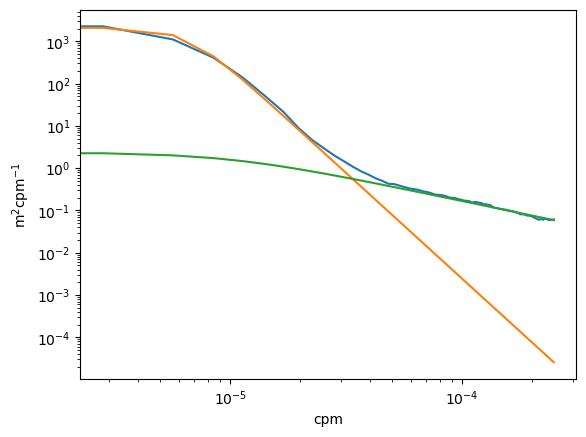

In [32]:
plt.loglog(k,specanom_gs1s,label = 'anomalies from high-pass 2D Gaussian time-mean and spatial mean')
plt.loglog(k,spec_b,label = 'balanced') # 1e-3*spec is to convert the unit from cm^2cpm^-1 to cm^2cpkm^-1
plt.loglog(k,spec_s,label = 'small-scale') 
print('fit: sigma_b=%5.3f, rho=%5.3f, s=%5.3f, A_s=%5.3f' %tuple(poptc))
plt.xlabel('cpm')
plt.ylabel('m$^{2}$cpm$^{-1}$')

In [33]:
leftind = np.where(good_strips_list[:,1]==0)[0]
rightind = np.where(good_strips_list[:,1]==1)[0]
leftstripe = ssha_arrayanomlysp_gs[good_strips_list[leftind,0],0,:,:]
rightstripe = ssha_arrayanomlysp_gs[good_strips_list[rightind,0],1,:,:]
n_cycles = rightstripe.shape[0]
n_samples = rightstripe.shape[0]

In [34]:
## South Pacific (SP)
dof1 = 2*n_cycles/10 # Degrees of freedom (number of cycles) assuming independent every 10 days
dof2 = 2*n_cycles
dof3 = 2*n_samples*25

alpha = 0.05
lower_factor1 = dof1 / chi2.ppf(1 - alpha/2, dof1)
lower_factor2 = dof2 / chi2.ppf(1 - alpha/2, dof2)
lower_factor3 = dof3 / chi2.ppf(1 - alpha/2, dof3)
upper_factor1 = dof1 / chi2.ppf(alpha/2, dof1)
upper_factor2 = dof2 / chi2.ppf(alpha/2, dof2)
upper_factor3 = dof3 / chi2.ppf(alpha/2, dof3)

In [35]:
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

<ErrorbarContainer object of 3 artists>

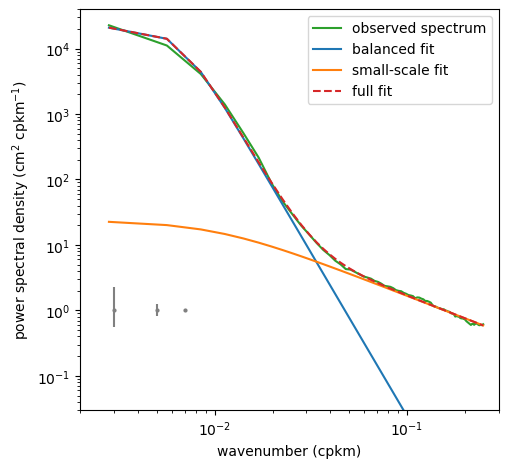

In [36]:
fig = plt.figure(figsize=(5, 4.6), constrained_layout=True)
fig.get_layout_engine().set(w_pad=4/72, h_pad=4/72, hspace=0.05, wspace=0.05)

plt.loglog(k[1:]*1e3, specanom_gs1s[1:]*10,color = colors[2],label = 'observed spectrum')
plt.loglog(k[1:]*1e3,spec_b[1:]*10,color = colors[0],label = 'balanced fit')
plt.loglog(k[1:]*1e3,spec_s[1:]*10,color = colors[1],label = 'small-scale fit')
plt.loglog(k[1:]*1e3,spec_s[1:]*10+spec_b[1:]*10,'--',color = colors[3],label = 'full fit')
plt.xlabel('wavenumber (cpkm)')
plt.ylabel('power spectral density (cm$^2$ cpkm$^{-1}$)')
plt.legend(loc = 'upper right')
plt.xlim(2e-3, 3e-1)
plt.ylim(3e-2, 4e4)
plt.errorbar([3e-3], [1], yerr=[[1-lower_factor1], [upper_factor1-1]], fmt='o', markersize=2, color="gray")
plt.errorbar([5e-3], [1], yerr=[[1-lower_factor2], [upper_factor2-1]], fmt='o', markersize=2, color="gray")
plt.errorbar([7e-3], [1], yerr=[[1-lower_factor3], [upper_factor3-1]], fmt='o', markersize=2, color="gray")

# plt.savefig('../paper_structure/southpacific_fit.pdf')

In [37]:
def newmodel_corr(rho,r): # for balanced signal 
    rnew = np.unique(r)
    covnew = np.empty(rnew.shape)
    covnew[:] = np.nan
    for i,j in enumerate(rnew):
        if j==0:
            covnew[i]=1
        else: 
            covnew[i] = (1/(0.34026*2*np.sqrt(5)*np.pi**(3/2)))*\
            float(mp.meijerg([[2/5],[]], [[0,1/5,2/5,2/5,3/5,4/5,9/10],[1/10,3/10,1/2,7/10]], ((j/(rho))**10)/1e10))
    sorted_indices = np.argsort(rnew)
    x_sorted = rnew[sorted_indices]
    y_sorted = covnew[sorted_indices]
    indices = np.searchsorted(x_sorted, r)
    y = y_sorted[indices]
    return y

In [38]:
def matern_corr_new(s,r):
    C = np.empty(r.shape)
    if np.any(r==0):
        C[r==0] = np.sqrt(np.pi)*gamma((s-1)/2)/(2*(100e3/2/np.pi)*gamma(s/2)) #(\lambda_s = 100e3/2pi)
        # C[r==0] = np.sqrt(np.pi)*(-3+s)*gamma(-3/2+s/2)/(4*100/2/np.pi*gamma(s/2))
        C[r!=0] = (2**(0.5-s/2)*np.sqrt(np.pi)*r[r!=0]**(-0.5+s/2)*(100e3/2/np.pi)**(-0.5-s/2)*kv(-0.5+s/2,r[r!=0]/(100e3/2/np.pi)))/(gamma(s/2))
    else:
        C = (2**(0.5-s/2)*np.sqrt(np.pi)*r**(-0.5+s/2)*(100e3/2/np.pi)**(-0.5-s/2)*kv(-0.5+s/2,r/(100e3/2/np.pi)))/(gamma(s/2))
    return C

In [39]:
delta = 2e3
nx = track_length
ny = 25
x = np.outer(np.arange(1, nx+1), np.ones(ny)) * delta
y = np.outer(np.ones(nx), np.arange(1, ny+1)) * delta
dx = np.subtract.outer(np.reshape(x,nx*ny),np.reshape(x,nx*ny))
dy = np.subtract.outer(np.reshape(y,nx*ny),np.reshape(y,nx*ny))
r = np.hypot(dx, dy)

In [40]:
C_hat = poptc[0]**2*newmodel_corr(poptc[1],r)
N = poptc[3]*matern_corr_new(poptc[2], r) 
# N = poptc[3]*matern_corr_new(poptc[2], r) 
C = inv(inv(N) + inv(C_hat))

In [41]:
lon_left = lon_strip[:,5:5+25]
lat_left = lat_strip[:,5:5+25]
lon_right = lon_strip[:,39:39+25]
lat_right = lat_strip[:,39:39+25]

In [42]:
f = 2*np.pi*np.sin(2*np.pi*lat_right/360)/(12*3600)

In [43]:
def vorticity(m,f,delta):
    psi = 9.8*m
    a = (psi[0:-2,:] - 2*psi[1:-1,:] + psi[2:,:])*(1/delta)**2 # f(dug/dy)
    b = (psi[:,0:-2] - 2*psi[:,1:-1]+ psi[:,2:])*(1/delta)**2 # f(dvg/dx)
    c0 = (psi[0:-1,:]-psi[1:,:])*(1/delta) # fug
    c = (c0[:,0:-1]-c0[:,1:])*(1/delta)# f(dug/dx) = f(d^2pi/dxdy)
    cfirst = c[:-1,:-1] 
    zetasg = (a[:,1:-1] + b[1:-1,:])*(1/f[1:-1,1:-1])+(-cfirst**2 + a[:,1:-1]*b[1:-1,:])*(1/f[1:-1,1:-1])**2
    return zetasg

In [44]:
m0 = C @ inv(N) @ np.reshape(rightstripe[18,:,:],(nx*ny,1))
m = m0.reshape((nx, ny))

In [45]:
zetasg_new = vorticity(m,f,delta)

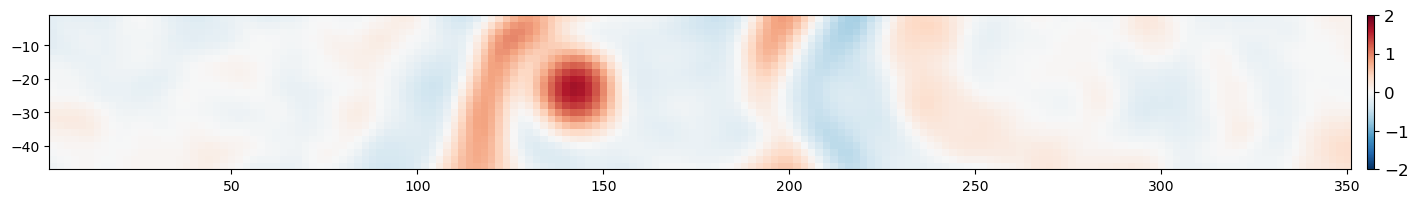

In [46]:
plt.figure(figsize=(20,2))
cl = plt.pcolormesh(x1[1:-1,1:-1],y1[1:-1,1:-1],(zetasg_new/f[1:-1,1:-1]).T,shading='nearest',vmin=-2,vmax=2)
cbar = plt.colorbar(cl,pad=0.01)
cbar.ax.tick_params(labelsize=12)
# plt.title(str(cycle_list[good_strips_list[n]]))
plt.set_cmap('RdBu_r')

In [47]:
cycleft = cycle_list[good_strips_list[leftind,0]]
cycleright = cycle_list[good_strips_list[rightind,0]]

In [48]:
dk=k[1]-k[0]
noiseamp=np.sqrt(np.sum(specanom_gs1s_ts[:,44:],axis=1)*dk)
# convert swot time
tswot=np.zeros(num_useful_strips)

import xarray as xr
import numpy as np

# Open your monthly model file
model_file = dirroot+'WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc'
ds = xr.open_dataset(model_file)

print(ds)

print('shape tswot:',np.shape(noiseamp),np.shape(tswot))
for strip in range(num_useful_strips):
    cycle_index = good_strips_list[strip,0]
    side_index = good_strips_list[strip,1]
    tswot[strip]=np.nanmean(time_array[cycle_index,side_index,:])
    
#timeswot = np.squeeze(time_array[good_strips_list,:])# time that when it measures each point 
epoch_time = datetime.datetime(1970, 1, 1)
dt = datetime.datetime(2000, 1, 1, 0, 0)
delta = (dt - epoch_time)

tswot_datetime = np.array([epoch_time + datetime.timedelta(seconds=(t + delta.total_seconds())) for t in tswot])



<xarray.Dataset>
Dimensions:    (latitude: 317, longitude: 720, time: 720)
Coordinates:
  * latitude   (latitude) float32 -78.0 -77.5 -77.0 -76.5 ... 79.0 79.5 80.0
  * longitude  (longitude) float32 -180.0 -179.5 -179.0 ... 178.5 179.0 179.5
  * time       (time) datetime64[ns] 2023-04-01 ... 2023-04-30T23:00:00
Data variables:
    MAPSTA     (latitude, longitude) int16 ...
    crs        |S1 ...
    fp         (time, latitude, longitude) float32 ...
    hs         (time, latitude, longitude) float32 ...
    qkk        (time, latitude, longitude) float32 ...
    skw        (time, latitude, longitude) float32 ...
    uwnd       (time, latitude, longitude) float32 ...
    vwnd       (time, latitude, longitude) float32 ...
Attributes: (12/101)
    WAVEWATCH_III_version_number:     7.14
    WAVEWATCH_III_switches:           NOGRB SCRIP SCRIPNC TRKNC DIST MPI PR3 ...
    SIN4 namelist parameter BETAMAX:  1.62
    title:                            WAVEWATCH-III FORECAST
    netcdf_version: 

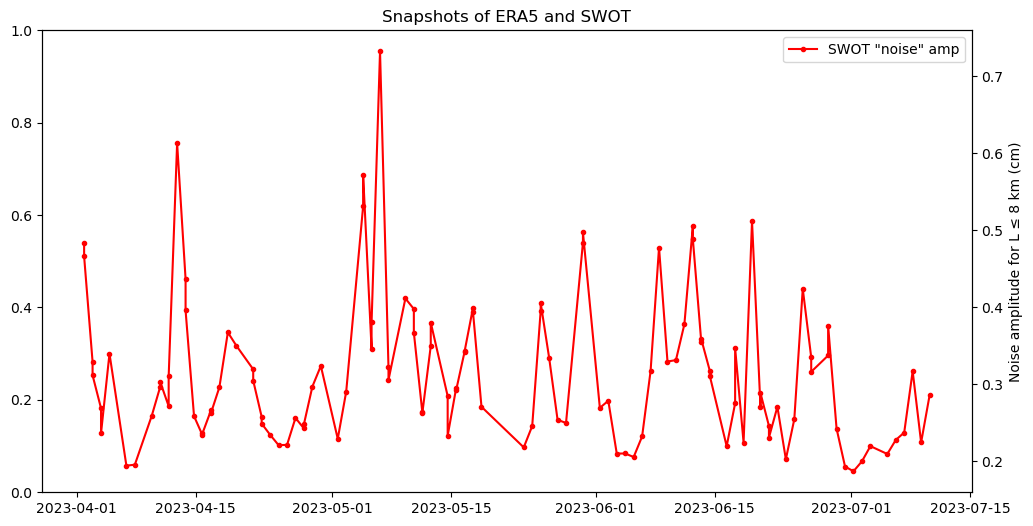

In [49]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
# ax1.plot(timesnap,swhmean[indxclose.astype(int)],'.-',label = 'Significant height of combined wind waves and swell')
#ax1.plot(tswot,swhmean[indxclose.astype(int)],'.-',label = 'Significant height of combined wind waves and swell')
# ax1.plot(tswotwave,swhswotmean,'.-',label = 'Significant wave height from SWOT')
# ax1.plot(timesnap,shwwmean[indxclose.astype(int)],'.-', label = 'Significant height of total swell')
# ax1.plot(timesnap,shtsmean[indxclose.astype(int)], '.-',label = 'Significant height of wind waves')
#ax1.set_ylabel('wave height [m]')
# ax1.set_xticks(t[0:len(t):10],lst_era5time)
# ax1.legend(



ax2.plot(tswot_datetime, 100 * noiseamp, 'r.-', label='SWOT "noise" amp')

ax2.set_ylabel('Noise amplitude for L ≤ 8 km (cm)')
ax2.set_title('Snapshots of ERA5 and SWOT')
ax2.legend()

# Format x-axis nicely
plt.show()


In [50]:
import numpy as np
import datetime

# Preallocate
lat_mean = np.zeros(len(good_strips_list))
lon_mean = np.zeros(len(good_strips_list))
tswot = np.zeros(len(good_strips_list))

for i, (cycle_index, side_index) in enumerate(good_strips_list):
    # Compute mean lat/lon (you can use median if you prefer)
    lat_mean[i] = np.nanmean(lat_array[cycle_index, side_index, :, :])
    lon_mean[i] = np.nanmean(lon_array[cycle_index, side_index, :, :])
    tswot[i] = np.nanmean(time_array[cycle_index, side_index, :])

epoch_time = datetime.datetime(1970, 1, 1)
dt = datetime.datetime(2000, 1, 1, 0, 0)
delta = (dt - epoch_time)

tswot_datetime = np.array([
    epoch_time + datetime.timedelta(seconds=(t + delta.total_seconds()))
    for t in tswot
])

# If your model were 0–360 instead, use: np.where(lon_mean < 0, lon_mean + 360, lon_mean)
# But from your ncdump, WW3 longitude = -180..180
lon_mean = np.where(lon_mean > 180, lon_mean - 360, lon_mean)


In [51]:
import glob
import xarray as xr
import numpy as np
import datetime
import pandas as pd
import os
model_dir = dirroot+"/WW3-CCI/"
model_files = sorted(glob.glob(os.path.join(model_dir, "CCI_WW3-GLOB-30M_2023??_hs.nc")))
print(model_files)


['/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202301_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202302_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202303_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202305_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202306_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202307_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202308_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202309_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202310_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202311_hs.nc', '/media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202312_hs.nc']


In [52]:
# Prepare storage
hs_model_all = np.full(len(tswot_datetime), np.nan)
qkk_model_all = np.full(len(tswot_datetime), np.nan)
fp_model_all = np.full(len(tswot_datetime), np.nan)
wnd_model_all = np.full(len(tswot_datetime), np.nan)

# Loop through available model files
for model_file in model_files:
    print(f"Processing {model_file}")
    ds = xr.open_dataset(model_file)
    
    # Extract start and end time of the model file
    tmin = pd.to_datetime(ds.time.values[0])
    tmax = pd.to_datetime(ds.time.values[-1])
    
    # Find which SWOT strips fall into this time range
    idx = np.where((tswot_datetime >= tmin) & (tswot_datetime <= tmax))[0]
    if len(idx) == 0:
        ds.close()
        continue
    
    # Subset SWOT data for this month
    lon_sub = lon_mean[idx]
    lat_sub = lat_mean[idx]
    time_sub = tswot_datetime[idx]
    #print('TEST:',idx,'##',lon_sub,'##',lat_sub,'##',time_sub)
    # Interpolate model data
    # Interpolate WW3 variables at SWOT positions/times
    hs_sub = ds['hs'].interp(longitude=('points', lon_sub),
                             latitude=('points', lat_sub),
                             time=('points', time_sub))
    
    fp_sub = ds['fp'].interp(longitude=('points', lon_sub),
                             latitude=('points', lat_sub),
                             time=('points', time_sub))
    
    qkk_sub = ds['qkk'].interp(longitude=('points', lon_sub),
                               latitude=('points', lat_sub),
                               time=('points', time_sub))

    wndu = ds['uwnd'].interp(longitude=('points', lon_sub),
                               latitude=('points', lat_sub),
                               time=('points', time_sub))
    wndv = ds['vwnd'].interp(longitude=('points', lon_sub),
                               latitude=('points', lat_sub),
                               time=('points', time_sub))

    
    # Store in arrays aligned with SWOT strips
    hs_model_all[idx] = hs_sub.values
    fp_model_all[idx] = fp_sub.values
    qkk_model_all[idx] = qkk_sub.values
    wnd_model_all[idx] = np.sqrt(wndu.values**2+wndv.values**2)
    ds.close()

df = pd.DataFrame({
    "time": tswot_datetime,
    "lat": lat_mean,
    "lon": lon_mean,
    "noiseamp_cm": 100 * noiseamp,
    "hs_model_m": hs_model_all,
    "wnd_model_m": wnd_model_all,
    "qkk_model_m": qkk_model_all,
    "fp_model_s-1": fp_model_all
})

df.to_csv("swot_ww3_colocation_2023_04to07.csv", index=False)


Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202301_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202302_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202303_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202305_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202306_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202307_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202308_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202309_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202310_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202311_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202312_hs.nc


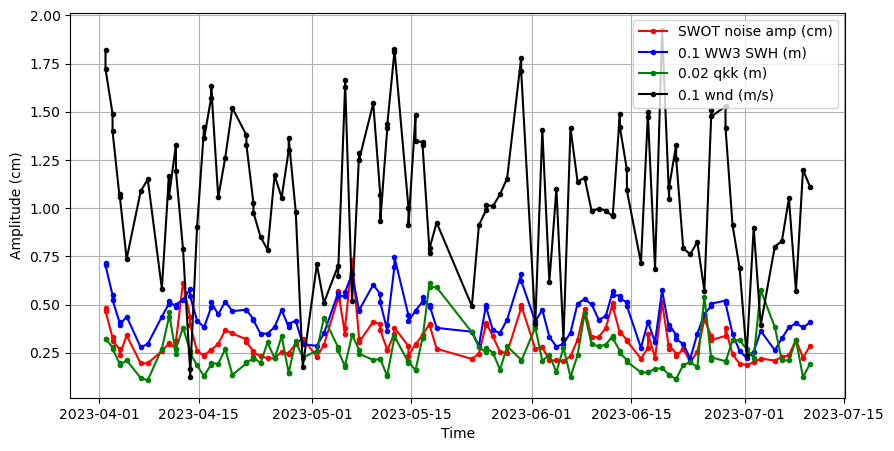

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["time"], df["noiseamp_cm"], 'r.-', label="SWOT noise amp (cm)")
plt.plot(df["time"], 0.1*df["hs_model_m"], 'b.-', label="0.1 WW3 SWH (m)")
plt.plot(df["time"], 0.02*df["qkk_model_m"], 'g.-', label="0.02 qkk (m)")
plt.plot(df["time"], 0.1*df["wnd_model_m"], 'k.-', label="0.1 wnd (m/s)")
#plt.plot(df["time"], 0.02*df["qkk_model_m"], 'g.-', label="WW3 qkk (m)")
plt.xlabel("Time")
plt.ylabel("Amplitude (cm)")
plt.legend()
plt.grid(True)
plt.show()



In [54]:
X=df["noiseamp_cm"]
Y=0.1*df["hs_model_m"]
Z=df["wnd_model_m"]  #*df["hs_model_m"]

import numpy as np
from scipy.stats import pearsonr

# Drop NaNs to avoid invalid correlations
mask = np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z)
Xc, Yc, Zc = X[mask], Y[mask], Z[mask]

# Pairwise Pearson correlation coefficients
r_XY, p_XY = pearsonr(Xc, Yc)
r_XZ, p_XZ = pearsonr(Xc, Zc)
r_YZ, p_YZ = pearsonr(Yc, Zc)

print(f"Corr(X, Y) = {r_XY:.3f}  (p={p_XY:.2e})")
print(f"Corr(X, Z) = {r_XZ:.3f}  (p={p_XZ:.2e})")
print(f"Corr(Y, Z) = {r_YZ:.3f}  (p={p_YZ:.2e})")


Corr(X, Y) = 0.771  (p=4.56e-24)
Corr(X, Z) = 0.127  (p=1.73e-01)
Corr(Y, Z) = 0.485  (p=3.36e-08)


Best-fit coefficients:
a = 8.7488e-01
b = -1.4243e-02
R² = 0.672


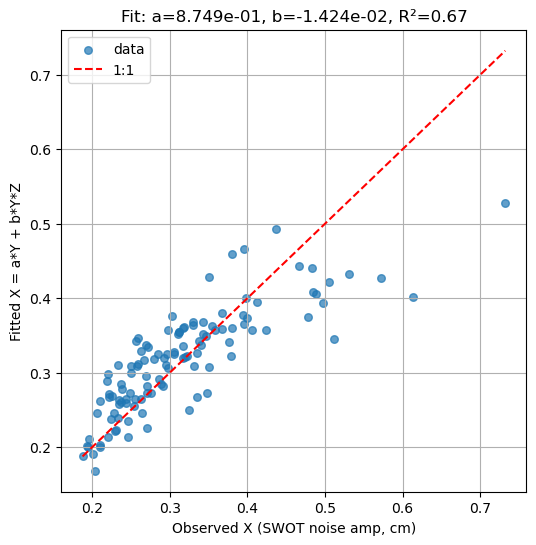

In [55]:
import numpy as np

# Define variables and remove NaNs
mask = np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z)
Xc, Yc, Zc = X[mask], Y[mask], Z[mask]

# Design matrix with columns [Y, Y*Z]
A = np.column_stack((Yc, Yc*Zc))

# Solve least squares fit: minimize ||A*[a, b] - X||
coeffs, residuals, rank, s = np.linalg.lstsq(A, Xc, rcond=None)
a, b = coeffs

print(f"Best-fit coefficients:")
print(f"a = {a:.4e}")
print(f"b = {b:.4e}")

# Compute fitted values and R²
X_fit = A @ coeffs
SS_res = np.sum((Xc - X_fit)**2)
SS_tot = np.sum((Xc - np.mean(Xc))**2)
R2 = 1 - SS_res/SS_tot
print(f"R² = {R2:.3f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(Xc, X_fit, s=30, alpha=0.7, label="data")
plt.plot([Xc.min(), Xc.max()], [Xc.min(), Xc.max()], 'r--', label="1:1")
plt.xlabel("Observed X (SWOT noise amp, cm)")
plt.ylabel("Fitted X = a*Y + b*Y*Z")
plt.title(f"Fit: a={a:.3e}, b={b:.3e}, R²={R2:.2f}")
plt.legend()
plt.grid(True)
plt.show()

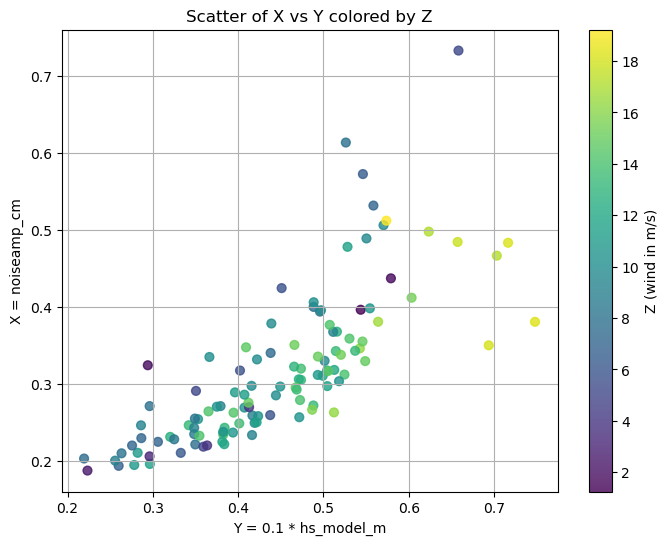

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Make sure all arrays have the same valid entries
mask = np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z)
Xc, Yc, Zc = X[mask], Y[mask], Z[mask]

plt.figure(figsize=(8,6))
sc = plt.scatter(Yc, Xc, c=Zc, cmap='viridis', s=40, alpha=0.8)
#plt.colorbar(sc, label='Z (sqrt(0.003*hs*qkk))')
plt.colorbar(sc, label='Z (wind in m/s)')
plt.xlabel('Y = 0.1 * hs_model_m')
plt.ylabel('X = noiseamp_cm')
plt.title('Scatter of X vs Y colored by Z')
plt.grid(True)
plt.show()


In [57]:
seg_length = 20  # along-track pixels (~40 km)
n_cross = 20     # total cross-track pixels
num_seg = track_length // seg_length
num_useful_strips = len(good_strips_list)

# Preallocate arrays for the segments
data_gs_seg = np.empty((num_useful_strips, num_seg, seg_length, n_cross))
lat_seg = np.empty((num_useful_strips, num_seg, seg_length, n_cross))
lon_seg = np.empty((num_useful_strips, num_seg, seg_length, n_cross))
time_seg = np.empty((num_useful_strips, num_seg, seg_length))
tswot_seg = np.empty((num_useful_strips, num_seg))

data_gs_seg[:] = np.nan
lat_seg[:] = np.nan
lon_seg[:] = np.nan
time_seg[:] = np.nan

for strip in range(num_useful_strips):
    cycle_index, side_index = good_strips_list[strip]
    if side_index==1:
        start_index=3
    else:
        start_index=2
        
    for s in range(num_seg):
        start_idx = s * seg_length
        end_idx = start_idx + seg_length
        data_gs_seg[strip, s, :, :] = data_array_gs[strip, start_idx:end_idx, start_index:start_index+n_cross]
        lat_seg[strip, s, :, :] = lat_array[cycle_index, side_index, start_idx:end_idx, start_index:start_index+n_cross]
        lon_seg[strip, s, :, :] = lon_array[cycle_index, side_index, start_idx:end_idx, start_index:start_index+n_cross]
        time_seg[strip, s, :] = time_array[cycle_index, side_index, start_idx:end_idx]

        #print(side_index,s,np.mean(lon_seg[strip, s, :, :]))

        
        tswot_seg[strip,s] = np.nanmean(time_seg[strip, s, :])



shape: (928, 20, 20)
full: [0.00012429 0.00012712 0.00012994 0.00013277 0.00013559 0.00013842
 0.00014124 0.00014407 0.00014689 0.00014972 0.00015254 0.00015537
 0.00015819 0.00016102 0.00016384 0.00016667 0.00016949 0.00017232
 0.00017514 0.00017797 0.00018079 0.00018362 0.00018644 0.00018927
 0.00019209 0.00019492 0.00019774 0.00020056 0.00020339 0.00020621
 0.00020904 0.00021186 0.00021469 0.00021751 0.00022034 0.00022316
 0.00022599 0.00022881 0.00023164 0.00023446 0.00023729 0.00024011
 0.00024294 0.00024576 0.00024859]
last k strip: 0.0002485875706214689 0.06146178139185872
last k seg: 0.00025 0.04986557210064312


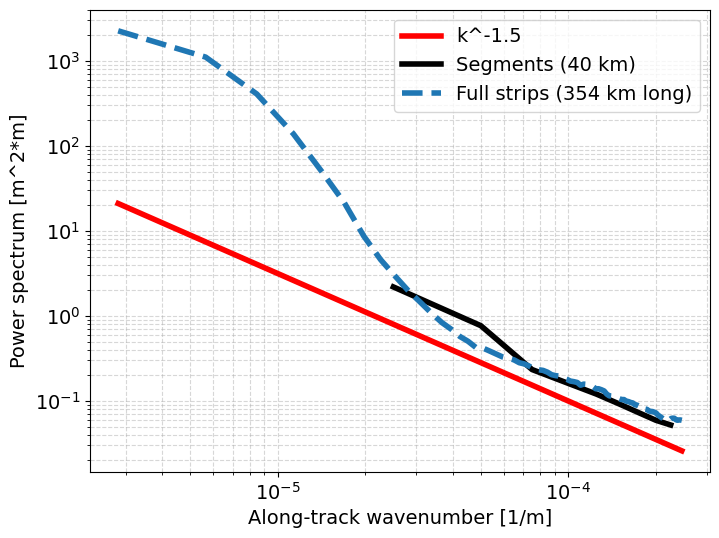

In [58]:
# Flatten the segments along the strip and segment dimensions
import matplotlib as mpl
mpl.rcParams.update({'figure.figsize':[10,6],'axes.grid' : True,'font.size': 14,'savefig.facecolor':'white'})

num_segments_total = num_useful_strips * num_seg
data_gs_seg_flat = data_gs_seg.reshape(num_segments_total, seg_length, n_cross)
print('shape:',np.shape(data_gs_seg_flat))
from scipy.signal import detrend

# detrend along the along-track axis (axis=1)
data_gs_seg_flat_detrended = detrend(data_gs_seg_flat, axis=1, type='linear')


# Compute 1-sided FFT for the segments using your existing function
specanom_gs_seg1s, specanom_gs_seg1s_ts = spectrum_compute_1sided(
    data_gs_seg_flat_detrended, num_segments_total, seg_length, ncross=n_cross)

# compute wavenumber axis
# Wavenumber for full strips
k_full = np.fft.rfftfreq(track_length, d=2e3)  # track_length = 177, spacing = 2 km

# Wavenumber for segments
k_seg = np.fft.rfftfreq(seg_length, d=2e3)     # seg_length = 20
print('full:',k_full[44:])
print('last k strip:',k_full[-1], specanom_gs1s[-1])
print('last k seg:',k_seg[-1], specanom_gs_seg1s[-1])

plt.figure(figsize=(8,6))
plt.loglog(k_full[1:-1], 0.1/(k_full[1:-1]/1E-4)**1.5, c='r',label='k^-1.5',linewidth=4, linestyle='-')
plt.loglog(k_seg[1:-1], specanom_gs_seg1s[1:-1],c='k',linewidth=4, label='Segments (40 km)')
plt.loglog(k_full[1:-1], specanom_gs1s[1:-1],linewidth=4, label='Full strips (354 km long)', linestyle='--')
plt.xlabel('Along-track wavenumber [1/m]')
plt.ylabel('Power spectrum [m^2*m]')
#plt.title('Along-track power spectra')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.savefig("Figure_1a.pdf")

In [59]:
# Assume dk is already defined (from np.fft.rfftfreq)
dk_seg=k_seg[1]-k_seg[0]
noiseamp_seg = np.sqrt(np.sum(specanom_gs_seg1s_ts[:, 5:], axis=1) * dk_seg)
noiseamp_seg = noiseamp_seg.reshape(num_useful_strips, num_seg)


In [60]:
import numpy as np
import pandas as pd
import datetime
import xarray as xr

# ----------------------------
# 1. Compute segment-mean lat/lon/time
# ----------------------------

# Preallocate arrays
lat_seg_mean = np.full((num_useful_strips, num_seg), np.nan)
lon_seg_mean = np.full((num_useful_strips, num_seg), np.nan)
tswot_seg_mean = np.full((num_useful_strips, num_seg), np.nan)

for i, (cycle_idx, side_idx) in enumerate(good_strips_list):
    lat_strip = lat_array[cycle_idx, side_idx, :, :]
    lon_strip = lon_array[cycle_idx, side_idx, :, :]
    time_strip = time_array[cycle_idx, side_idx, :]
    
    n_along = lat_strip.shape[0]
    seg_edges = np.linspace(0, n_along, num_seg + 1, dtype=int)
    
    for s in range(num_seg):
        idx_start = seg_edges[s]
        idx_end = seg_edges[s + 1]
        
        # Cross-track mean
        lat_seg_mean[i, s] = np.nanmean(lat_strip[idx_start:idx_end, :])
        lon_seg_mean[i, s] = np.nanmean(lon_strip[idx_start:idx_end, :])
        tswot_seg_mean[i, s] = np.nanmean(time_strip[idx_start:idx_end])

# Flatten to 1D arrays for DataFrame and interpolation
lat_seg_mean_flat = lat_seg_mean.flatten()
lon_seg_mean_flat = lon_seg_mean.flatten()
tswot_seg_mean_flat = tswot_seg_mean.flatten()
noiseamp_seg_flat = noiseamp_seg.flatten()  # already matches shape

num_segments_total = lat_seg_mean_flat.size

# Convert to datetime
epoch_time = datetime.datetime(1970, 1, 1)
dt_ref = datetime.datetime(2000, 1, 1)
delta = (dt_ref - epoch_time).total_seconds()

tswot_seg_datetime = np.array([
    epoch_time + datetime.timedelta(seconds=(t + delta))
    for t in tswot_seg_mean_flat
])

# Fix longitudes if necessary
lon_seg_mean_flat = np.where(lon_seg_mean_flat > 180, lon_seg_mean_flat - 360, lon_seg_mean_flat)

# ----------------------------
# 2. Interpolate WW3 model variables
# ----------------------------

hs_model_seg = np.full(num_segments_total, np.nan)
qkk_model_seg = np.full(num_segments_total, np.nan)
wnd_model_seg = np.full(num_segments_total, np.nan)
fp_model_seg = np.full(num_segments_total, np.nan)

for model_file in model_files:
    print(f"Processing {model_file}")
    ds = xr.open_dataset(model_file)
    
    tmin = pd.to_datetime(ds.time.values[0])
    tmax = pd.to_datetime(ds.time.values[-1])
    
    tswot_seg_pd = pd.to_datetime(tswot_seg_datetime)
    idx = np.where((tswot_seg_pd >= tmin) & (tswot_seg_pd <= tmax))[0]
    
    if len(idx) == 0:
        ds.close()
        continue
    
    hs_sub = ds['hs'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                             latitude=('points', lat_seg_mean_flat[idx]),
                             time=('points', tswot_seg_pd[idx]))
    
    fp_sub = ds['fp'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                             latitude=('points', lat_seg_mean_flat[idx]),
                             time=('points', tswot_seg_pd[idx]))
    
    qkk_sub = ds['qkk'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                               latitude=('points', lat_seg_mean_flat[idx]),
                               time=('points', tswot_seg_pd[idx]))
    wndu = ds['uwnd'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                               latitude=('points', lat_seg_mean_flat[idx]),
                               time=('points', tswot_seg_pd[idx]))
    wndv = ds['vwnd'].interp(longitude=('points', lon_seg_mean_flat[idx]),
                               latitude=('points', lat_seg_mean_flat[idx]),
                               time=('points', tswot_seg_pd[idx]))
    
    hs_model_seg[idx] = hs_sub.values
    fp_model_seg[idx] = fp_sub.values
    qkk_model_seg[idx] = qkk_sub.values
    wnd_model_seg[idx] = np.sqrt(wndu.values**2+wndv.values**2)
    
    ds.close()

# ----------------------------
# 3. Build DataFrame
# ----------------------------


df_seg = pd.DataFrame({
    "strip_segment_idx": np.repeat(np.arange(num_useful_strips), num_seg),
    "segment_idx": np.tile(np.arange(num_seg), num_useful_strips),
    "lat": lat_seg_mean_flat,
    "lon": lon_seg_mean_flat,
    "time": tswot_seg_datetime,
    "noiseamp_cm": 100 * noiseamp_seg_flat,
    "hs_model_m": hs_model_seg,
    "qkk_model_m": qkk_model_seg,
    "wnd_model_m": wnd_model_seg,
    "fp_model_s-1": fp_model_seg
})

# ----------------------------
# 4. Save CSV
# ----------------------------
df_seg.to_csv("swot_ww3_colocation_segments_segment_avg.csv", index=False)
print(f"Saved CSV with {num_segments_total} segment points.")


Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202301_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202302_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202303_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202304_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202305_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202306_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202307_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202308_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202309_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202310_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202311_hs.nc
Processing /media/ardhuin/FabLinux//WW3-CCI/CCI_WW3-GLOB-30M_202312_hs.nc
Saved CSV with 928 segment points.


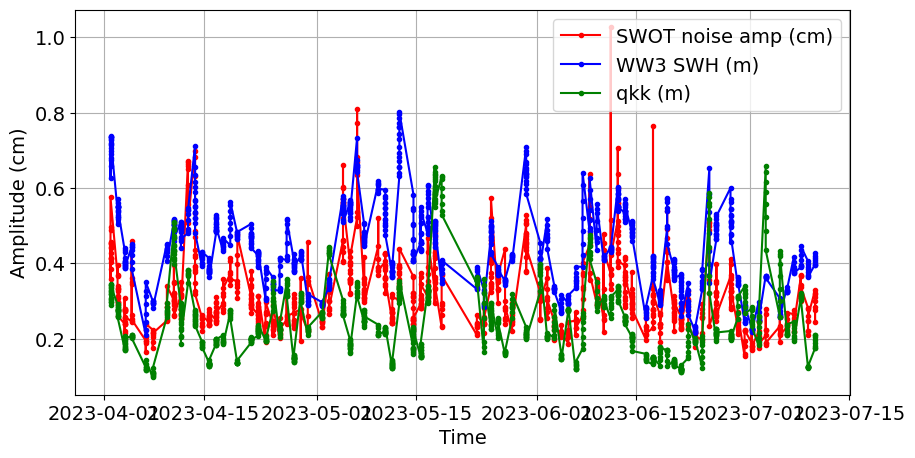

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_seg["time"], df_seg["noiseamp_cm"], 'r.-', label="SWOT noise amp (cm)")
plt.plot(df_seg["time"], 0.1*df_seg["hs_model_m"], 'b.-', label="WW3 SWH (m)")
plt.plot(df_seg["time"], 0.02*df_seg["qkk_model_m"], 'g.-', label="qkk (m)")
#plt.plot(df["time"], 0.02*df["qkk_model_m"], 'g.-', label="WW3 qkk (m)")
plt.xlabel("Time")
plt.ylabel("Amplitude (cm)")
plt.legend()
plt.grid(True)
plt.show()


In [62]:
X=df_seg["noiseamp_cm"]
Y=df_seg["hs_model_m"]**1
Z=df_seg["wnd_model_m"]
#Z=1/df_seg["fp_model_s-1"]
import numpy as np
from scipy.stats import pearsonr

# Drop NaNs to avoid invalid correlations
mask = np.isfinite(X) & np.isfinite(Y) & np.isfinite(Z)
#print('mask:',X[1240:1262],Y[1240:1262],Z[1240:1262])
Xc, Yc, Zc = X[mask], Y[mask], Z[mask]

# Pairwise Pearson correlation coefficients
r_XY, p_XY = pearsonr(Xc, Yc)
r_XZ, p_XZ = pearsonr(Xc, Zc)
r_YZ, p_YZ = pearsonr(Yc, Zc)

print('len:',len(Xc),len(X),len(Y),len(Z),len(X[mask]))
print(f"Corr(X, Y) = {r_XY:.3f}  (p={p_XY:.2e})")
print(f"Corr(X, Z) = {r_XZ:.3f}  (p={p_XZ:.2e})")
print(f"Corr(Y, Z) = {r_YZ:.3f}  (p={p_YZ:.2e})")


len: 928 928 928 928 928
Corr(X, Y) = 0.670  (p=5.41e-122)
Corr(X, Z) = 0.154  (p=2.60e-06)
Corr(Y, Z) = 0.532  (p=7.30e-69)


/tmp/ipykernel_6141/704107830.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = plt.scatter(Yc, Xc, cmap='viridis', s=20, alpha=1)  #c=Zc


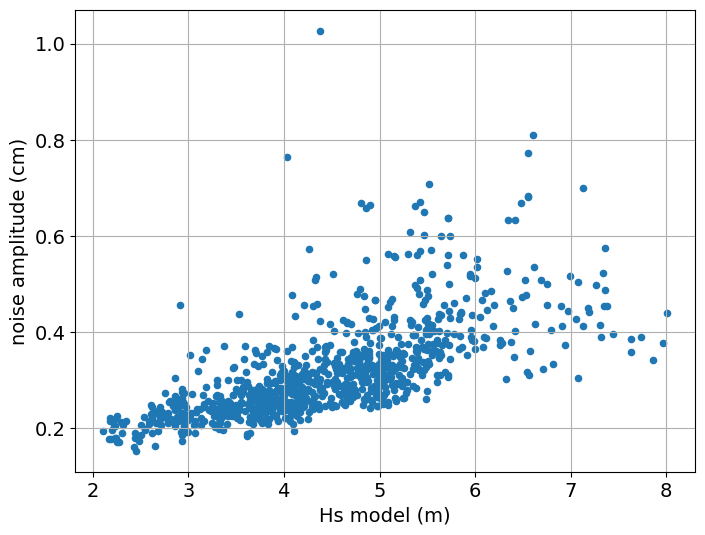

In [63]:

plt.figure(figsize=(8,6))
sc = plt.scatter(Yc, Xc, cmap='viridis', s=20, alpha=1)  #c=Zc
#plt.colorbar(sc, label='wnd (m/s)')
plt.xlabel('Hs model (m)')
plt.ylabel('noise amplitude (cm)')
#plt.title('Scatter of X vs Y colored by Z')
plt.grid(True)
plt.savefig("Figure_1b2.pdf")

In [67]:
import sys as sys
sys.path.append('/home/ardhuin/TOOLS/swellSWOT/src/')
from spectral_analysis_functions import *
from scipy.ndimage import uniform_filter

dx=2000;dy=2000
X=np.arange(20)*dx/1000;
m=1;n=1;i1=0;i2=21;j1=0;j2=21

noise_10k = np.full((num_useful_strips, num_seg), np.nan)
noise_10l = np.full((num_useful_strips, num_seg), np.nan)
noise_10m = np.full((num_useful_strips, num_seg), np.nan)
noise_10n = np.full((num_useful_strips, num_seg), np.nan)

EtameanL=np.zeros((20,20))
EtameanR=np.zeros((20,20))
nfx_2k=20
nfy_2k=20

Efxfy_2k = np.full((num_useful_strips, num_seg, nfy_2k, nfx_2k), np.nan)



nmeanL=0
nmeanR=0
for i, (cycle_idx, side_idx) in enumerate(good_strips_list):
    
    for s in range(num_seg):
        mybox=data_gs_seg[i, s, :, :]
        flbox=mybox*0+1
        myboh=mybox
        (Eta,Etb,ang,angstd,coh,crosr,phases,ky2,kx2,dky,dkx,detrenda,detrendb,nspec)=FFT2D_two_arrays_nm_detrend_flag(mybox,myboh,flbox,dy,dx,n,m,detrend='quadratic') #,ffill='none')
        Efxfy_2k[i, s, :, :]=Eta
        if (i==0 & s==0):
#            ind1 = np.where((abs(kx2) < 1.5E-4) & (abs(ky2) > 0.00012))[0]
            ind1 = np.where((abs(ky2) > 0.00012))[0]
            ind2 = np.where((abs(kx2) > 2.4E-4) & (abs(ky2) > 0.00012))[0]
            ind3 = np.where((abs(kx2) < 0.00012) & (abs(ky2) < 0.00012))[0]
            ind4 = np.where((abs(kx2) > 1.2E-4) & (abs(ky2) > 1.2E-4) &(abs(kx2) < 2.4E-4) & (abs(ky2) < 2.4E-4))[0]
            #ind4 = np.where((abs(kx2) > 0.25E-4) & (abs(ky2) > 0.25E-4) &(abs(kx2) < 2.4E-4) & (abs(ky2) < 2.4E-4))[0]
        if not np.isnan(Eta[0,0]):
            if side_idx==0:
                EtameanL=EtameanL+Eta
                nmeanL=nmeanL+1
            else:
                EtameanR=EtameanR+Eta
                nmeanR=nmeanR+1
            dkx=ky2[1,0]-ky2[0,0]
            dky=kx2[0,1]-kx2[0,0]
            #print(np.var(mybox.flatten()),np.var(detrenda.flatten()),np.sum(Eta.flatten())*dkx*dky)
        
            varm=np.sum(Eta[ind1]*dkx*dky)
            noise_10k[i,s]=100*np.sqrt(varm)
            varm=np.sum(Eta[ind2]*dkx*dky)
            noise_10l[i,s]=100*np.sqrt(varm)
            varm=np.var(detrenda.flatten()) #np.sum(Eta[ind3]*dkx*dky)
            noise_10m[i,s]=100*np.sqrt(varm)
            varm=np.sum(Eta.flatten())*dkx*dky #np.sum(Eta[ind4]*dkx*dky)
            noise_10n[i,s]=100*np.sqrt(varm)
# Flatten to 1D arrays for DataFrame and interpolation
noise_10k_flat = noise_10k.flatten()
noise_10l_flat = noise_10l.flatten()
noise_10m_flat = noise_10m.flatten()
noise_10n_flat = noise_10n.flatten()



# ------------------------------------------------------------
# 2) Collapse scenes + segments → time dimension
# ------------------------------------------------------------
print("Shape of Efxfy_2k:", np.shape(Efxfy_2k))
E = Efxfy_2k.reshape(-1, nfy_2k, nfx_2k)
Nt = E.shape[0]
print("Shape of E:", np.shape(E))

print("Ensemble size:", Nt)

mask = (abs(ky2) > 0.00012)

# ------------------------------------------------------------
# 5) Spectral correlation function
# ------------------------------------------------------------
def spectral_correlation_map(E, mask):
    """
    E : array (Nt, nfy, nfx)
    mask : boolean mask selecting spectral region
    """
    

    # Reference time series (energy in selected band)
    E_ref = np.nansum(E[:, mask], axis=1)
    #E_ref=np.log10(E_ref+1E-12)
    #E=np.log10(E+1E-12)
    # Remove temporal mean
    E = uniform_filter(E, size=(1, 3, 3), mode='nearest')
    E_anom = E - np.nanmean(E, axis=0)
    ref_anom = E_ref - np.nanmean(E_ref)

    # Standard deviations
    E_std = np.nanstd(E_anom, axis=0)
    ref_std = np.nanstd(ref_anom)

    # Covariance
    cov = np.nanmean(E_anom * ref_anom[:, None, None], axis=0)

    # Correlation
    corr = cov / (E_std * ref_std)

    return corr, E_ref


# ------------------------------------------------------------
# 6) Compute correlation map
# ------------------------------------------------------------
corr_map, E_ref = spectral_correlation_map(E, mask)


Shape of Efxfy_2k: (116, 8, 20, 20)
Shape of E: (928, 20, 20)
Ensemble size: 928


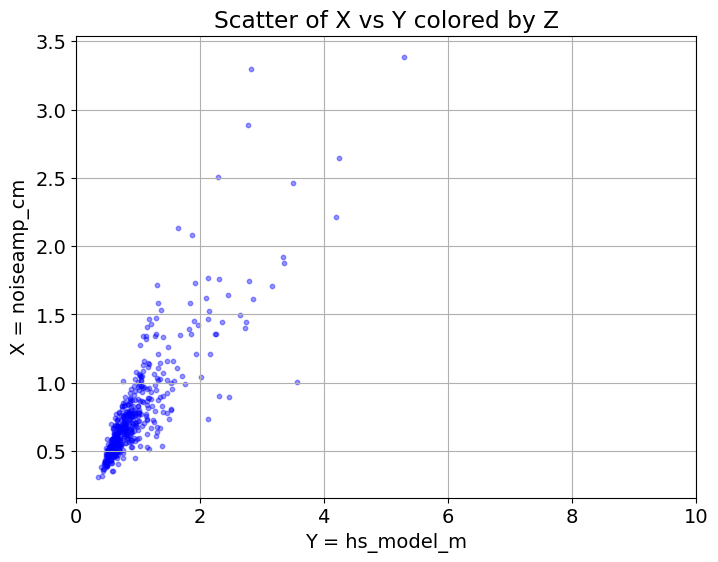

In [68]:
plt.figure(figsize=(8,6))
#sc = plt.scatter(df_seg["noiseamp_cm"], noise_10k_flat, c=df_seg["noiseamp_cm"], cmap='viridis', s=20, alpha=0.8)
#sc = plt.scatter(df_seg["noiseamp_cm"], 2*noise_10l_flat, c='k', s=10, alpha=0.8)
#sc = plt.scatter(0.2*noise_10k_flat, noise_10l_flat, c='r', s=10, alpha=0.8)
#sc = plt.scatter(0.1*noise_10m_flat, noise_10l_flat, c='b', s=10, alpha=0.2)
#sc = plt.scatter(0.3*noise_10n_flat, noise_10m_flat, c='m', s=10, alpha=0.2)

#sc = plt.scatter(df_seg["noiseamp_cm"], noise_10k_flat, c='k',  s=10, alpha=0.4)
sc = plt.scatter(noise_10m_flat, noise_10n_flat, c='b',  s=10, alpha=0.4)
plt.xlim([0,10])


#plt.colorbar(sc, label='Qkk (m)')
plt.xlabel('Y = hs_model_m')
plt.ylabel('X = noiseamp_cm')
plt.title('Scatter of X vs Y colored by Z')
plt.grid(True)
plt.show()

In [69]:
import sys as sys
sys.path.append('/Users/ardhuin/TOOLS/swellSWOT/src/')
import swot_ssh_utils as swot
from  spectral_analysis_functions import *
import matplotlib.colors as mcolors
import cmocean
import cmocean.cm as cmo

hemiNS=['A','N','S']
hemiWE=['A','E','W']
lightcmap = cmocean.tools.lighten(cmo.ice, 1)
lightcmap2 = cmocean.tools.lighten(cmo.ice_r, 1)

dx=2000;dy=2000
X=np.arange(20)*dx/1000;
m=1;n=1;i1=0;i2=21;j1=0;j2=21
dBE=10;dBE2=10;amax=0.2;fs1=20; # font size
fshrink=0.8;

indsub0=0
Y=(np.arange(20)+indsub0)*dy/1000 
strip=1
s=4

latc=lat_seg_mean[strip, s]; latcr=np.round(latc*2)/2; latcs=f'{abs(latc):3.2f}'+hemiNS[int(np.sign(latc))]
lonc=lon_seg_mean[strip, s]; loncr=np.round(lonc*2)/2; loncs=f'{abs(lonc):3.2f}'+hemiWE[int(np.sign(lonc))]


mybox=data_gs_seg[strip, s, :, :]
flbox=mybox*0+1
myboh=mybox
(Eta,Etb,ang,angstd,coh,crosr,phases,ky2,kx2,dky,dkx,detrenda,detrendb,nspec)=FFT2D_two_arrays_nm_detrend_flag(mybox,myboh,flbox,dy,dx,n,m,detrend='quadratic') #,ffill='none')


# ---- 250m to 2 km Hamming filter (see SWOT ATBD) ----
wf = 17
nfy=160;nfx=160
# -------------------------------------------------
# 1D Hamming windows
# -------------------------------------------------
m = np.arange(wf)
hx = 0.54 - 0.46 * np.cos(2 * np.pi * m / (wf - 1))
hy = hx.copy()  # same in y

# -------------------------------------------------
# Build separable 2D filter
# -------------------------------------------------
F2d = np.outer(hx, hy)
# Normalize
H2d = F2d / np.sum(F2d)

# -------------------------------------------------
# Embed in full spectral grid
# -------------------------------------------------
kernel = np.zeros((nfx, nfy))

# place filter in corner
kernel[:wf, :wf] = H2d

# shift to make zero-phase centered
kernel = np.fft.ifftshift(kernel)

# -------------------------------------------------
# Compute 2D FFT
# -------------------------------------------------
Hspec = np.fft.fft2(kernel)
Hspec = np.fft.fftshift(Hspec)

Hmag = np.abs(Hspec).T


H2D_spectrum = Hmag[70:70+20,70:70+20]**2
factorU=np.mean(H2D_spectrum.flatten())
print('Factor for U2:',factorU)

Factor for U2: 0.4008289122884358


ratio for true noise amplitude: 2.086920223387918
[0.02697062 0.02825636 0.03195888 0.03818738 0.04792691 0.05928015
 0.07384467 0.10422711 0.23504327 0.56746665 0.66922907 0.56746665
 0.23504327 0.10422711 0.07384467 0.05928015 0.04792691 0.03818738
 0.03195888 0.02825636] ## [-2.50e-04 -2.25e-04 -2.00e-04 -1.75e-04 -1.50e-04 -1.25e-04 -1.00e-04
 -7.50e-05 -5.00e-05 -2.50e-05  0.00e+00  2.50e-05  5.00e-05  7.50e-05
  1.00e-04  1.25e-04  1.50e-04  1.75e-04  2.00e-04  2.25e-04]
var from Emean: 7.671456111503731e-05
var from Eky: 7.671456111503731e-05
var from 1D: 9.403649952368632e-05


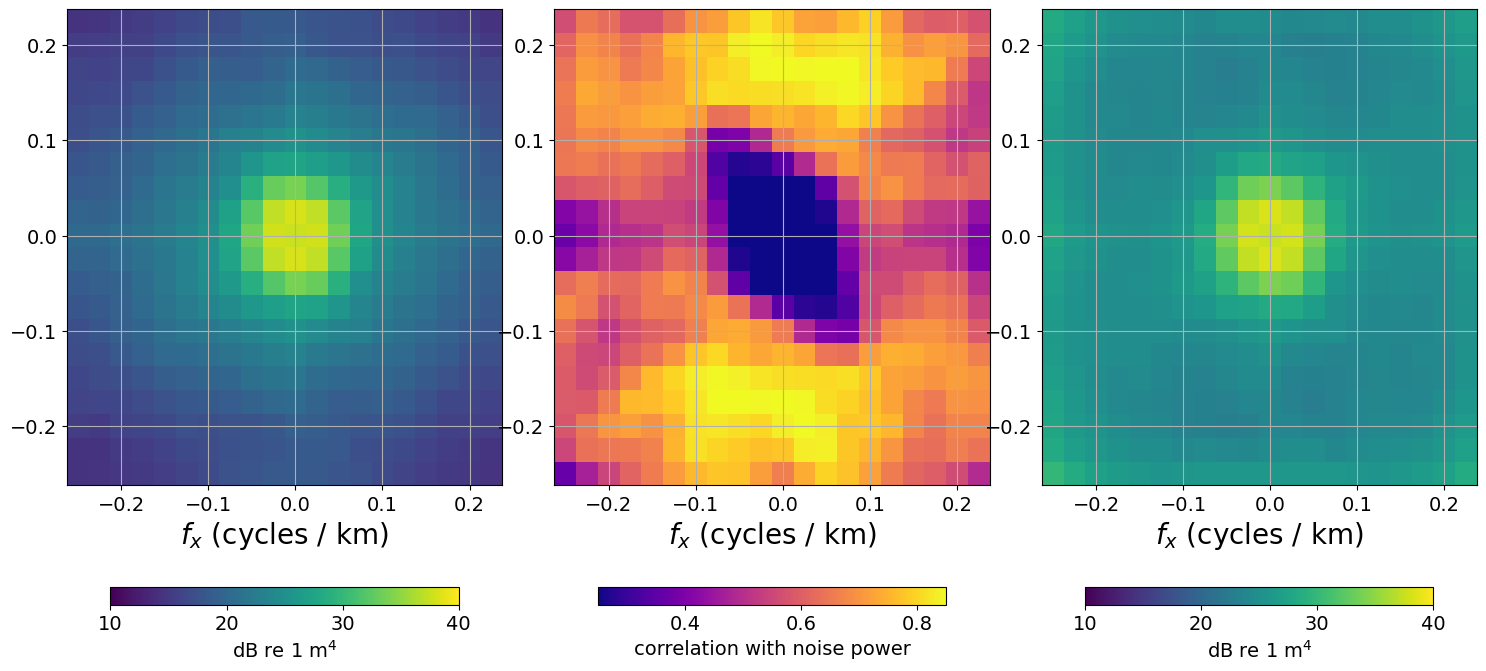

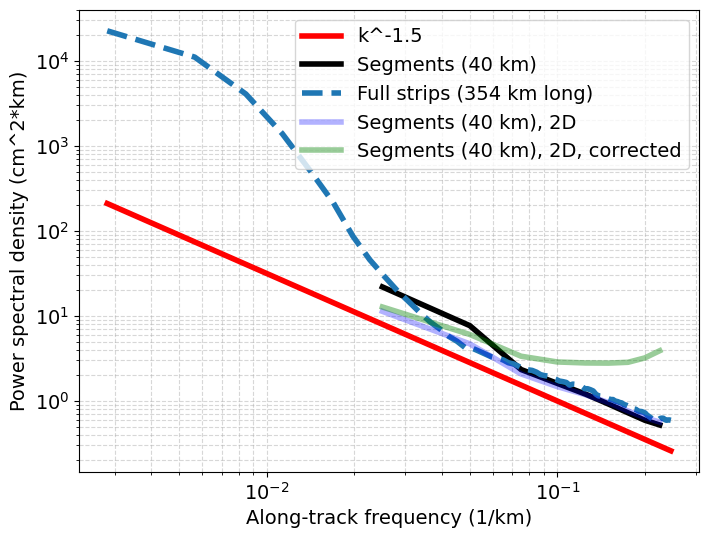

In [71]:
    knorm=np.sqrt(kx2**2+ky2**2)*1000
    fig,ax2s=plt.subplots(1,3,figsize=(15,8));axs=ax2s.T.flatten()
    plt.subplots_adjust(left=0.05,bottom=0.07, top=0.92,wspace=0.12,right=0.99)

Emean2D=(EtameanR+EtameanL)/(nmeanR+nmeanL)

# warning: we use an array img1 that is written with X in the first (number 0) dimension and Y in the second
#          but pcolormesh uses the opposite order: hence the use of transpose 

#    im=axs[0].pcolormesh(X[i1:i2],Y[j1:j2],detrenda,rasterized=True, cmap=lightcmap,vmin=-amax,vmax=amax) 
#    _=plt.colorbar(im,ax=axs[0],label='surface elevation (m)', location='bottom',shrink=fshrink)
#    _=axs[0].set_xlabel('cross-track (km)', fontsize=fs1)
#    _=axs[0].set_ylabel('along-track (km)',fontsize=fs1)
#    _=axs[0].set_title('Detrended SSH at '+latcs+' '+loncs)


    im=axs[0].pcolormesh(kx2*1000,ky2*1000,10*np.log10(Emean2D),cmap='viridis',norm = mcolors.Normalize(vmin =10, vmax=40),rasterized=True)
    _=plt.colorbar(im,ax=axs[0],label='dB re 1 m$^4$', location='bottom',shrink=fshrink)
    _=axs[0].set_xlabel('$f_x$ (cycles / km)', fontsize=fs1)


    im=axs[1].pcolormesh(kx2*1000,ky2*1000,corr_map,cmap='plasma',norm = mcolors.Normalize(vmin = 0.25, vmax=0.85),rasterized=True)
    _=plt.colorbar(im,ax=axs[1],label='correlation with noise power', location='bottom',shrink=fshrink)
    _=axs[1].set_xlabel('$f_x$ (cycles / km)', fontsize=fs1)


#    im=axs[1].pcolormesh(kx2*1000,ky2*1000,10*np.log10(EtameanR/nmeanR*knorm**2),norm = mcolors.Normalize(vmin = -10+dBE2, vmax=10+dBE2),rasterized=True)

#im=axs[2].pcolormesh(kx2*1000,ky2*1000,10*np.log10(EtameanR/nmeanR*(knorm/0.1)**2),cmap='viridis',norm = mcolors.Normalize(vmin =20, vmax=30),rasterized=True)
im=axs[2].pcolormesh(kx2*1000,ky2*1000,10*np.log10(Emean2D/H2D_spectrum),cmap='viridis',norm = mcolors.Normalize(vmin =10, vmax=40),rasterized=True)
    _=plt.colorbar(im,ax=axs[2],label='dB re 1 m$^4$', location='bottom',shrink=fshrink)
    _=axs[2].set_xlabel('$f_x$ (cycles / km)', fontsize=fs1)
    #_=axs[1].set_ylabel('$k_y$ (cycles / km)', fontsize=fs1)
    #_=axs[1].set_title('Spectrum for track '+tracks+' on '+days )

plt.savefig("Figure_2part.pdf")

mask = (abs(knorm) > 0.00008)


ind1 = np.where((abs(ky2) > 0.00012))[0]
var_filt=np.sum(Emean2D[ind1])
var_true=np.sum(Emean2D[ind1]/H2D_spectrum[ind1])
ratio=np.sqrt(var_true/var_filt)
print('ratio for true noise amplitude:',ratio)

dkx=ky2[1,0]-ky2[0,0]
dky=kx2[0,1]-kx2[0,0]
dk_seg=k_seg[1]-k_seg[0]

Ekyc=np.sum(Emean2D/H2D_spectrum,axis=0)*dkx
Eky=np.sum(Emean2D,axis=0)*dkx
Ekx=np.sum(EtameanR/nmeanR/H2D_spectrum,axis=1)*dkx
print(Eky,'##',ky2[:,0])

print('var from Emean:',np.sum(Emean2D*dky*dkx))
print('var from Eky:',np.sum(Eky*dky))
print('var from 1D:',np.sum(specanom_gs_seg1s[1:-1]*dk_seg))
plt.figure(figsize=(8,6))
mpl.rcParams.update({'figure.figsize':[10,6],'axes.grid' : True,'font.size': 14,'savefig.facecolor':'white'})
plt.loglog(1000*k_full[1:-1], 1/(k_full[1:-1]/1E-4)**1.5, c='r',label='k^-1.5',linewidth=4, linestyle='-')
plt.loglog(1000*k_seg[1:-1], 10*specanom_gs_seg1s[1:-1],c='k',linewidth=4, label='Segments (40 km)')
plt.loglog(1000*k_full[1:-1], 10*specanom_gs1s[1:-1],linewidth=4, label='Full strips (354 km long)', linestyle='--')
plt.loglog(1000*ky2[11:,0], 10*2*Eky[11:], c='b',alpha=0.3,linewidth=4, label='Segments (40 km), 2D')
plt.loglog(1000*ky2[11:,0], 10*2*Ekyc[11:], c='g',alpha=0.4,linewidth=4, label='Segments (40 km), 2D, corrected')
plt.xlabel('Along-track frequency (1/km)')
plt.ylabel('Power spectral density (cm^2*km)')
#plt.title('Along-track power spectra')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.savefig("Figure_1a.pdf")